# Demand Forecasting — 8-Week Ahead (Recursive + Rolling Validation)
**Stack:** Gradient Boosting · Recursive multi-step · Walk-forward CV · Baseline comparison




## 1 · Setup

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn --quiet

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
warnings.filterwarnings("ignore")
print("Ready")


Ready




```
# This is formatted as code
```

## 2 · Uploading Data

In [12]:

promotions_df = pd.read_csv(promotions_path)

print("Files loaded successfully!")
print("\nDemand shape:", demand_df.shape)
print("Promotions shape:", promotions_df.shape)

display(demand_df.head())
display(promotions_df.head())


Files loaded successfully!

Demand shape: (9855, 4)
Promotions shape: (15, 4)


,date,demand,sku,supermarket
0,1/1/2019,93.0,Organic Milk,FreshMart
1,1/2/2019,93.0,Organic Milk,FreshMart
2,1/3/2019,94.0,Organic Milk,FreshMart
3,1/4/2019,95.0,Organic Milk,FreshMart
4,1/5/2019,92.0,Organic Milk,FreshMart


,Unnamed: 0,promotion_date,sku,supermarket
0,0,9/26/2020,Organic Milk,DailyNeeds
1,1,9/18/2019,Organic Milk,DailyNeeds
2,2,9/28/2021,Organic Milk,DailyNeeds
3,3,2/11/2021,Organic Milk,DailyNeeds
4,0,10/3/2021,Organic Milk,GreenBasket


## 3 · Loading, Cleaning & Aggregating

**Outlier handling — IQR (Tukey fence):**  
`upper = Q3 + 1.5 × IQR`   
Outliers are replaced with NaN and then forward-filled within each group.


In [13]:
demand = pd.read_csv("demand.csv", parse_dates=["date"])
promos = pd.read_csv("promotions.csv", parse_dates=["promotion_date"])
promos = promos.drop(columns=["Unnamed: 0"], errors="ignore")

# IQR outlier cap
demand = demand.sort_values(["supermarket", "sku", "date"])
for (sm, sku), idx in demand.groupby(["supermarket", "sku"]).groups.items():
    s = demand.loc[idx, "demand"]
    fence = s.quantile(0.75) + 1.5 * (s.quantile(0.75) - s.quantile(0.25))
    demand.loc[idx[s > fence], "demand"] = np.nan

# Impute + aggregate to weekly
demand["demand"] = demand.groupby(["supermarket","sku"])["demand"].transform(
    lambda s: s.ffill().bfill())
demand["week"] = demand["date"].dt.to_period("W").apply(lambda p: p.start_time)
weekly = (demand.groupby(["week","supermarket","sku"])["demand"]
          .sum().reset_index(name="y"))

# Promotion flag
promos["week"] = promos["promotion_date"].dt.to_period("W").apply(lambda p: p.start_time)
weekly = weekly.merge(
    promos[["week","supermarket","sku"]].assign(is_promo=1),
    on=["week","supermarket","sku"], how="left")
weekly["is_promo"] = weekly["is_promo"].fillna(0).astype(int)

print(f"Weeks: {weekly['week'].nunique()}  |  "
      f"Combos: {weekly.groupby(['supermarket','sku']).ngroups}  |  "
      f"Promo weeks: {weekly['is_promo'].sum()}")
weekly.head(3)


Weeks: 157  |  Combos: 9  |  Promo weeks: 15


,week,supermarket,sku,y,is_promo
0,2018-12-31,DailyNeeds,Free Range Eggs,405.0,0
1,2018-12-31,DailyNeeds,Organic Milk,572.0,0
2,2018-12-31,DailyNeeds,Whole Wheat Bread,308.0,0


## 4 · Quick EDA

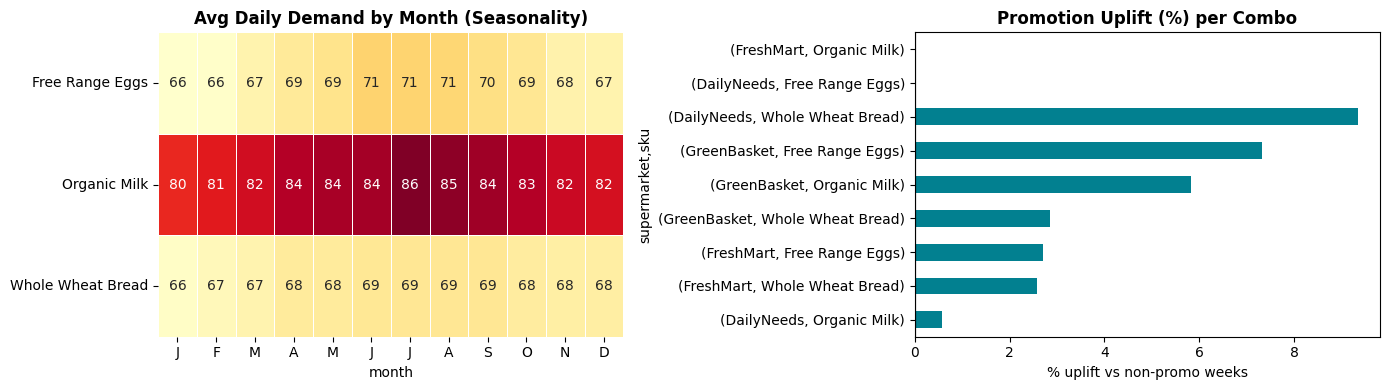

Overall promo uplift: 4.5%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Seasonality heatmap
demand["month"] = demand["date"].dt.month
pivot = demand.groupby(["sku","month"])["demand"].mean().unstack()
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            xticklabels=["J","F","M","A","M","J","J","A","S","O","N","D"],
            ax=axes[0], linewidths=.4, cbar=False)
axes[0].set_title("Avg Daily Demand by Month (Seasonality)", fontweight="bold")
axes[0].set_ylabel("")

# Promo uplift
up = ((weekly[weekly.is_promo==1].groupby(["supermarket","sku"])["y"].mean() /
       weekly[weekly.is_promo==0].groupby(["supermarket","sku"])["y"].mean()) - 1).mul(100)
up.sort_values().plot(kind="barh", ax=axes[1], color="#028090")
axes[1].axvline(0, color="k", lw=.8)
axes[1].set_title("Promotion Uplift (%) per Combo", fontweight="bold")
axes[1].set_xlabel("% uplift vs non-promo weeks")

plt.tight_layout(); plt.show()
print(f"Overall promo uplift: {up.mean():.1f}%")


## 5 · Feature Engineering

Lag features capture temporal dependence in demand.

Week and month are encoded using sine/cosine features to model seasonality.

Future lag values are generated recursively during forecasting to avoid data leakage.

In [8]:
le_sm  = LabelEncoder().fit(weekly["supermarket"])
le_sku = LabelEncoder().fit(weekly["sku"])

LAGS    = [1, 2, 4, 8, 13, 26, 52]
FEATURE_COLS = (["sm_enc","sku_enc","wk_sin","wk_cos","month_sin","month_cos",
                 "trend","is_promo"] +
                [f"lag_{l}" for l in LAGS] +
                ["roll4","roll8","roll_std4"])

def featurise(df):
    df = df.copy().sort_values(["supermarket","sku","week"])
    df["sm_enc"]    = le_sm.transform(df["supermarket"])
    df["sku_enc"]   = le_sku.transform(df["sku"])
    wn = df["week"].dt.isocalendar().week.astype(int)
    df["wk_sin"]    = np.sin(2*np.pi*wn/52)
    df["wk_cos"]    = np.cos(2*np.pi*wn/52)
    df["month_sin"] = np.sin(2*np.pi*df["week"].dt.month/12)
    df["month_cos"] = np.cos(2*np.pi*df["week"].dt.month/12)
    df["trend"]     = (df["week"] - df["week"].min()).dt.days // 7
    for l in LAGS:
        df[f"lag_{l}"] = df.groupby(["supermarket","sku"])["y"].shift(l)
    sh = df.groupby(["supermarket","sku"])["y"].shift(1)
    df["roll4"]      = sh.transform(lambda s: s.rolling(4,  min_periods=2).mean())
    df["roll8"]      = sh.transform(lambda s: s.rolling(8,  min_periods=2).mean())
    df["roll_std4"]  = sh.transform(lambda s: s.rolling(4,  min_periods=2).std())
    return df

weekly = featurise(weekly)
print(f"Features built: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Features built: 18
['sm_enc', 'sku_enc', 'wk_sin', 'wk_cos', 'month_sin', 'month_cos', 'trend', 'is_promo', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_13', 'lag_26', 'lag_52', 'roll4', 'roll8', 'roll_std4']


**6 · Baseline Models**




Before claiming a model is good, always compare it to simple baselines.
If Gradient Boosting can't beat these, it's not adding value.

In [ ]:
def baseline_naive(hist, horizon=8):
    #Last known value repeated (random walk).
    return [float(hist.iloc[-1])] * horizon

def baseline_seasonal_naive(hist, horizon=8, period=52):
    #Same week last year — captures annual seasonality.
    return [float(hist.iloc[-(period - i)] if len(hist) >= period else hist.mean())
            for i in range(horizon)]

print("Baselines defined: Naive (last value) | Seasonal Naive (same week last year)")


Baselines defined: Naive (last value) | Seasonal Naive (same week last year)


## 7 · Recursive 8-Week Forecaster

**Why recursive?**  
To forecast Week 108 from Week 100, values such as `lag_1` (Week 107) are not yet available.

Recursive forecasting solves this by predicting one week at a time, using each prediction as a lag feature for the next forecast.

```
Predict Week+1  →  use as lag_1 for Week+2
Predict Week+2  →  use as lag_1, lag_2 for Week+3
...
Predict Week+8
```


In [10]:
def recursive_forecast(model, combo_history, sm, sku, origin_week, horizon=8):

    sm_enc  = le_sm.transform([sm])[0]
    sku_enc = le_sku.transform([sku])[0]


    hist = list(
        combo_history.loc[(combo_history.supermarket==sm) &
                          (combo_history.sku==sku) &
                          (combo_history.week<=origin_week), "y"].values
    )
    origin_trend = int((origin_week - weekly["week"].min()).days // 7)
    preds = []

    for step in range(1, horizon + 1):
        fw = origin_week + pd.Timedelta(weeks=step)
        wn = fw.isocalendar()[1]
        n  = len(hist)

        row = {
            "sm_enc":    sm_enc,
            "sku_enc":   sku_enc,
            "wk_sin":    np.sin(2*np.pi*wn/52),
            "wk_cos":    np.cos(2*np.pi*wn/52),
            "month_sin": np.sin(2*np.pi*fw.month/12),
            "month_cos": np.cos(2*np.pi*fw.month/12),
            "trend":     origin_trend + step,
            "is_promo":  0,
        }
        # Lags: pull from hist (mix of actuals and prior predictions)
        for l in LAGS:
            row[f"lag_{l}"] = hist[n - l] if n - l >= 0 else np.nan
        tail1 = hist[max(0,n-4):n]
        tail2 = hist[max(0,n-8):n]
        row["roll4"]     = np.mean(tail1)  if tail1 else np.nan
        row["roll8"]     = np.mean(tail2)  if tail2 else np.nan
        row["roll_std4"] = np.std(tail1, ddof=1) if len(tail1)>1 else 0.0

        X = pd.DataFrame([row])[FEATURE_COLS].fillna(np.mean(hist))
        pred = float(max(0, model.predict(X)[0]))
        preds.append((fw, round(pred, 1)))
        hist.append(pred)

    return preds


## 8 · Walk-Forward Validation

Walk-forward validation evaluates the model across multiple forecasting origins.

This better reflects real-world forecasting than a single train/test split.

```
Origin 1 → train on weeks 1…T  → forecast T+1…T+8 → measure error
Origin 2 → train on weeks 1…T+8 → forecast T+9…T+16 → measure error
…repeat every 8 weeks
```


In [11]:
HORIZON      = 8
MIN_TRAIN    = 60   # need at least 60 weeks before first forecast
combos       = weekly[["supermarket","sku"]].drop_duplicates().values.tolist()
all_weeks    = sorted(weekly["week"].unique())

# Rolling origins: every 8 weeks, starting after MIN_TRAIN weeks
origins = all_weeks[MIN_TRAIN:-HORIZON:HORIZON]
print(f"Rolling origins : {len(origins)}  (every {HORIZON} weeks)")
print(f"First origin    : {origins[0].date()}   Last: {origins[-1].date()}")
print(f"Combos          : {len(combos)}")
print("\nRunning... (may take ~60-90 seconds)")

records = []

for origin in origins:
    train_df = weekly[weekly["week"] <= origin].dropna(subset=FEATURE_COLS+["y"])
    if len(train_df) < 50:
        continue

    # Train GB on all data up to this origin
    model = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=42)
    model.fit(train_df[FEATURE_COLS], train_df["y"])

    # Actuals for the next 8 weeks
    future = weekly[(weekly["week"] > origin) &
                    (weekly["week"] <= origin + pd.Timedelta(weeks=HORIZON))]

    for sm, sku in combos:
        act_rows = future[(future.supermarket==sm) & (future.sku==sku)].sort_values("week")
        if len(act_rows) < HORIZON:
            continue
        actuals = act_rows["y"].values[:HORIZON]

        hist_s = weekly[(weekly.week<=origin) &
                        (weekly.supermarket==sm) & (weekly.sku==sku)].sort_values("week")["y"]
        if len(hist_s) < 10:
            continue

        # GB
        gb_preds = np.array([v for _,v in
                             recursive_forecast(model, weekly, sm, sku, origin, HORIZON)])
        # Baselines
        nv_preds = np.array(baseline_naive(hist_s, HORIZON))
        sn_preds = np.array(baseline_seasonal_naive(hist_s, HORIZON))

        for step,(act,gb,nv,sn) in enumerate(zip(actuals,gb_preds,nv_preds,sn_preds),1):
            records.append(dict(supermarket=sm, sku=sku, origin=origin,
                                step=step, actual=act,
                                gb=gb, naive=nv, seasonal_naive=sn))

results = pd.DataFrame(records)
print(f"\n Done — {len(results):,} predictions across {len(origins)} origins.")


Rolling origins : 12  (every 8 weeks)
First origin    : 2020-02-24   Last: 2021-11-01
Combos          : 9

Running... (may take ~60-90 seconds)

 Done — 864 predictions across 12 origins.


## 9 · Results — Model vs Baselines

In [10]:
def smape(a, f):
    a, f = np.array(a), np.array(f)
    d = (np.abs(a) + np.abs(f)) / 2
    return np.where(d==0, 0, np.abs(a-f)/d).mean() * 100

models = {"Gradient Boosting (recursive)": "gb",
          "Seasonal Naive":                "seasonal_naive",
          "Naive (last value)":            "naive"}

print(f"{'Model':<35} {'SMAPE%':>8}  {'MAE':>8}")
print("-" * 55)
rows = []
for name, col in models.items():
    s = smape(results.actual, results[col])
    m = mean_absolute_error(results.actual, results[col])
    print(f"{name:<35} {s:>8.1f}  {m:>8.1f}")
    rows.append({"model":name, "SMAPE":round(s,1), "MAE":round(m,1)})

comparison = pd.DataFrame(rows)


Model                                 SMAPE%       MAE
-------------------------------------------------------
Gradient Boosting (recursive)            3.0      14.6
Seasonal Naive                           4.2      20.4
Naive (last value)                       2.6      12.5


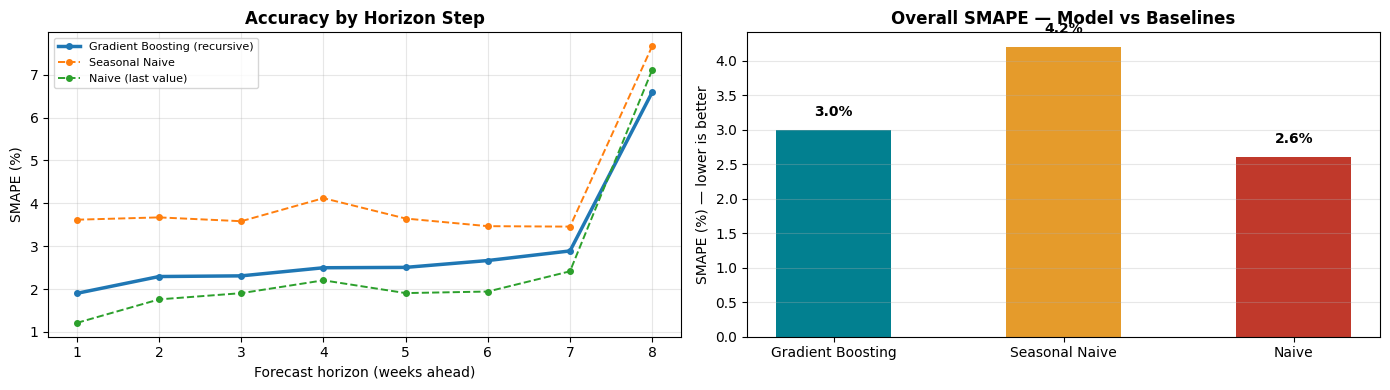

In [11]:
# Accuracy by horizon step
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, col in models.items():
    step_smape = [smape(results[results.step==s].actual,
                        results[results.step==s][col]) for s in range(1,9)]
    lw = 2.5 if "Boosting" in name else 1.4
    ls = "-"  if "Boosting" in name else "--"
    axes[0].plot(range(1,9), step_smape, label=name, lw=lw, ls=ls, marker="o", ms=4)

axes[0].set_xlabel("Forecast horizon (weeks ahead)")
axes[0].set_ylabel("SMAPE (%)")
axes[0].set_title("Accuracy by Horizon Step", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(1,9))

# Bar chart overall SMAPE
colors = ["#028090","#E59B2B","#C0392B"]
bars = axes[1].bar([r["model"].split(" (")[0] for r in rows],
                   [r["SMAPE"] for r in rows], color=colors, width=0.5)
for b, r in zip(bars, rows):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+.2,
                 f'{r["SMAPE"]}%', ha="center", fontweight="bold", fontsize=10)
axes[1].set_title("Overall SMAPE — Model vs Baselines", fontweight="bold")
axes[1].set_ylabel("SMAPE (%) — lower is better")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()


## 10 · Final 8-Week Forward Forecast

In [ ]:
# Training on all available data, then forecasting 8 weeks into the future
clean_all = weekly.dropna(subset=FEATURE_COLS+["y"])
final_model = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.04,
    max_depth=4, subsample=0.8, random_state=42)
final_model.fit(clean_all[FEATURE_COLS], clean_all["y"])

last_week = weekly["week"].max()
print(f"Forecasting 8 weeks from {last_week.date()}\n")

fc_rows = []
for sm, sku in combos:
    for week, val in recursive_forecast(final_model, weekly, sm, sku, last_week, 8):
        fc_rows.append({"week":week, "supermarket":sm, "sku":sku, "forecast":int(val)})

fc_df = pd.DataFrame(fc_rows)
pivot = fc_df.pivot_table(index=["supermarket","sku"], columns="week", values="forecast")
pivot.columns = [c.strftime("%d-%b") for c in pivot.columns]
print(pivot.to_string())


Forecasting 8 weeks from 2021-12-27

                               03-Jan  10-Jan  17-Jan  24-Jan  31-Jan  07-Feb  14-Feb  21-Feb
supermarket sku                                                                              
DailyNeeds  Free Range Eggs     318.0   286.0   278.0   262.0   270.0   269.0   265.0   256.0
            Organic Milk        407.0   399.0   389.0   326.0   349.0   339.0   307.0   304.0
            Whole Wheat Bread   249.0   249.0   249.0   235.0   235.0   239.0   239.0   233.0
FreshMart   Free Range Eggs     259.0   258.0   263.0   255.0   253.0   247.0   249.0   255.0
            Organic Milk        390.0   368.0   354.0   333.0   336.0   307.0   309.0   300.0
            Whole Wheat Bread   241.0   238.0   234.0   227.0   229.0   233.0   234.0   228.0
GreenBasket Free Range Eggs     324.0   294.0   293.0   267.0   276.0   273.0   277.0   262.0
            Organic Milk        212.0   226.0   216.0   218.0   218.0   220.0   228.0   218.0
            Whole Wheat

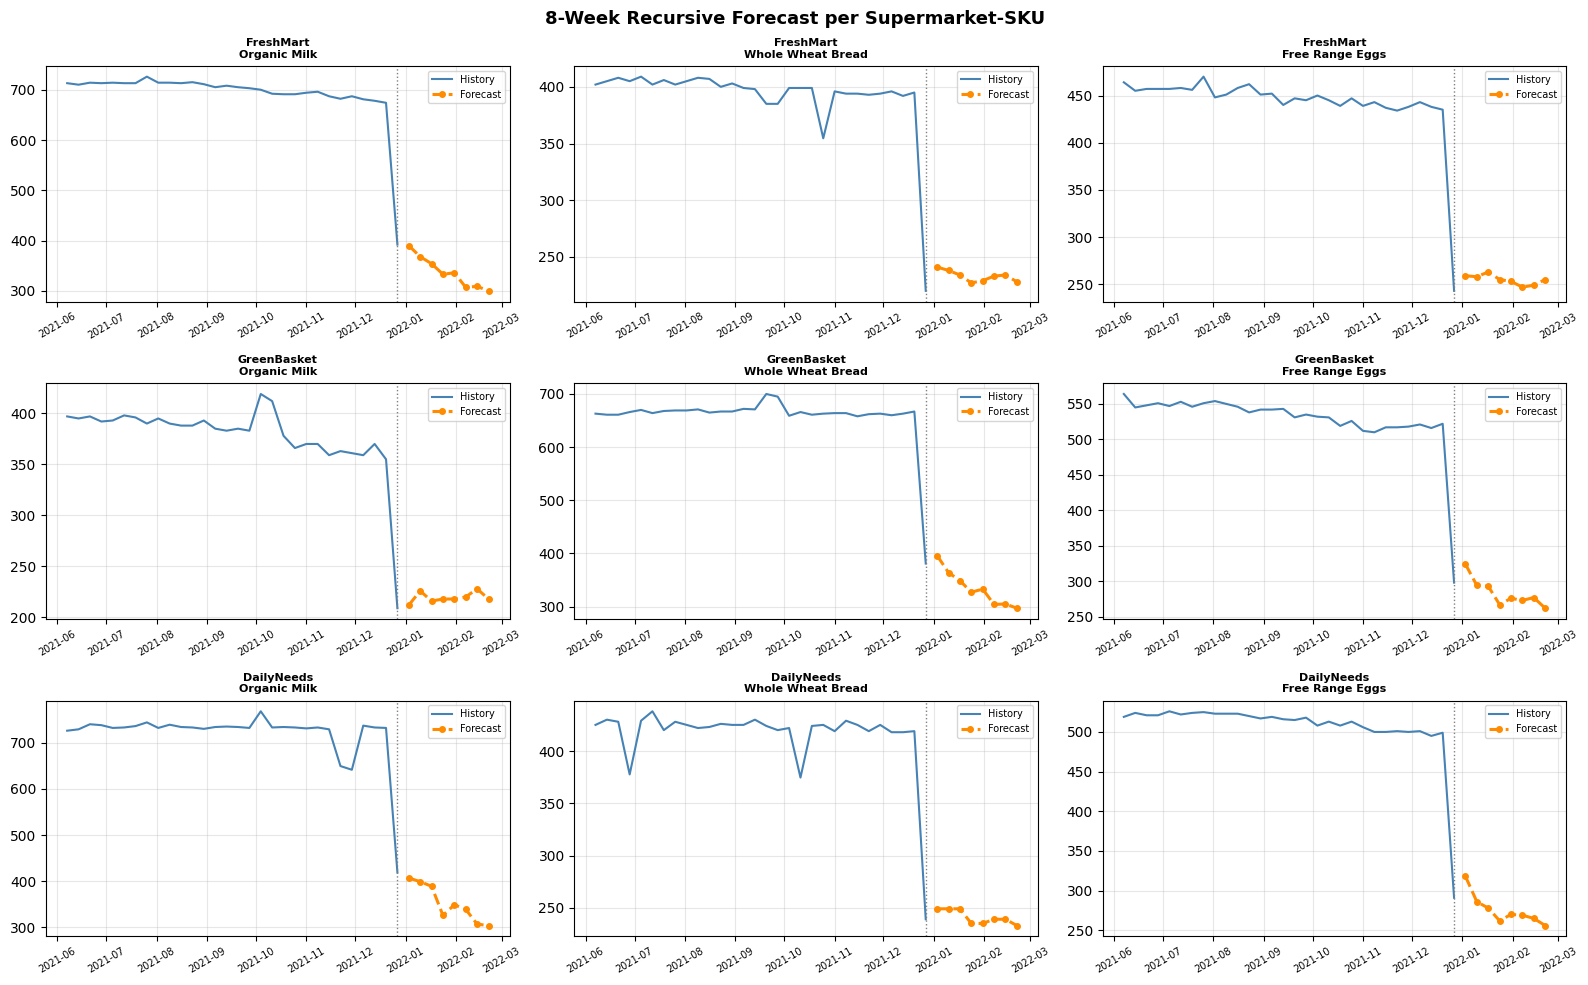

In [ ]:
# Plotting history + forecasting for all 9 combos
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle("8-Week Recursive Forecast per Supermarket-SKU", fontsize=13, fontweight="bold")

for ax, (sm, sku) in zip(axes.flat,
    [("FreshMart","Organic Milk"),("FreshMart","Whole Wheat Bread"),("FreshMart","Free Range Eggs"),
     ("GreenBasket","Organic Milk"),("GreenBasket","Whole Wheat Bread"),("GreenBasket","Free Range Eggs"),
     ("DailyNeeds","Organic Milk"),("DailyNeeds","Whole Wheat Bread"),("DailyNeeds","Free Range Eggs")]):
    h = weekly[(weekly.supermarket==sm)&(weekly.sku==sku)].tail(30)
    f = fc_df[(fc_df.supermarket==sm)&(fc_df.sku==sku)]
    ax.plot(h["week"], h["y"], color="steelblue", lw=1.5, label="History")
    ax.plot(f["week"], f["forecast"], color="darkorange", lw=2.2,
            ls="--", marker="o", ms=4, label="Forecast")
    ax.axvline(last_week, color="gray", ls=":", lw=1)
    ax.set_title(f"{sm}\n{sku}", fontsize=8, fontweight="bold")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=7)

plt.tight_layout(); plt.show()


## 11 · Download Results

In [ ]:
fc_df.to_csv("forecast_8weeks.csv", index=False)
results.to_csv("rolling_eval_results.csv", index=False)
comparison.to_csv("model_comparison.csv", index=False)
print("Saved: forecast_8weeks.csv | rolling_eval_results.csv | model_comparison.csv")

from google.colab import files
files.download("forecast_8weeks.csv")
files.download("model_comparison.csv")


---
## Summary

| Fix | What changed |
|-----|-------------|
| **Recursive forecast** | Predictions feed back as lags — no future data used |
| **Rolling validation** | Walk-forward across multiple origins, not a single split |
| **Baselines compared** | Gradient Boosting vs Naive vs Seasonal Naive |
| **IQR outlier removal** | Tukey fence (Q3 + 1.5×IQR) — statistically principled |

**Primary metric: SMAPE** — symmetric, scale-independent, penalises over- and under-forecast equally.  
Both matter here: under-forecast → stock-out; over-forecast → write-off.
